{'poem': '《莲》\n素魄澄波净，幽芳隔浦微。\n影斜凉月堕，香动晚风归。\n露重房初结，泥深节自持。\n若为湘水畔，长伴芰荷衣。\n\n赏析：这首作品以莲花为吟咏对象，通过“素魄澄波”“幽芳隔浦”等意象勾勒出莲之清雅形态。中二联“影斜凉月堕，香动晚风归”以动衬静，展现月下风中的莲韵；“露重房初结，泥深节自持”则暗含君子洁身自好之志。尾联借湘水典故，寄托超然物外的隐逸情怀。', 'ci_poem': '《莲华辞》\n（以楚辞体咏莲，循香草美人遗韵）\n\n余既滋兰之九畹兮，更树蕙以百亩\n爰濯缨于清涟兮，植芙蕖于南浦\n朝饮沆瀣之坠露兮，夕餐落英之芳序\n揽青霓以为佩兮，纫秋兰以为裾\n\n观夫陂塘淼渺兮，有菡萏初举\n翠盖亭亭如云兮，朱华灼灼若炬\n出淤淖而不缁兮，处淟涊而愈楚\n中通外直若君子兮，香远益清如古\n\n忽惊飙之骤起兮，摧百草为萧艾\n虽零落其未改兮，犹抱芳心以待\n岂效女萝之附木兮，耻同菟丝缠芥\n宁曳尾于泥涂兮，不折腰于埃壒\n\n湘灵鼓瑟江皋兮，冯夷击鼓河渚\n采菱舟子何往兮，遗佩佳人已去\n惟余清影摇波兮，共明月而长语\n恐鹈鴂之先鸣兮，使百芳皆迟暮\n\n乱曰：芙蓉泣露兮秋气深，寒潭鹤影兮空寂岑。纵使霜雪凛冽至，自有冰心鉴古今。', 'joke': '莲花池边，一只蜻蜓对荷花说：“你知道吗？你出淤泥而不染，濯清涟而不妖，简直是花中君子！”\n\n荷花优雅地抖了抖花瓣：“谢谢夸奖，不过我更羡慕你——‘小荷才露尖尖角，早有蜻蜓立上头’，你可是诗里的常客。”\n\n蜻蜓叹了口气：“别提了，自从我站上你尖尖角那天，所有游客都冲我喊‘看！那是杨万里写的那只！’——可我是个母蜻蜓啊。”\n\n荷花愣了：“这有什么讲究？”\n\n蜻蜓幽怨地扇扇翅膀：“他们每天对着我念‘小荷才露尖尖角’……可我叫翠翠，不叫‘小荷’！更惨的是，上周有个小孩非要给我改名，说从此叫我‘小尖尖’……”\n\n荷花笑得花瓣直颤：“那你怎么不飞走？”\n\n蜻蜓悲愤道：“我飞走三回，他们又写‘飞入菜花无处寻’——这下好了，全池子的蝴蝶都以为我是来抢镜头的！”', 'topic': '莲花'}


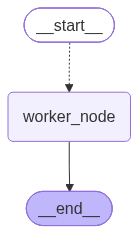

In [14]:
from typing import TypedDict, Literal, Sequence

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send

load_dotenv(override=True)

CONTENT_TYPES = ["poem", "joke", "ci_poem"]

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {"type": "disabled"}
    }
)

# ====================== 状态定义 ======================
class InputState(TypedDict):
    topic: str

class OutputState(TypedDict):
    poem: str
    ci_poem: str
    joke: str
    topic: str

class WorkerState(TypedDict):
    content_type: Literal["poem", "joke", "ci_poem"]
    prompt: str
    topic: str  # 必须带上，用于合并

# ====================== 节点 ======================
def worker_node(state: WorkerState):
    prompt = state["prompt"]
    res = model.invoke([HumanMessage(content=prompt)])
    return {
        state["content_type"]: res.content
    }


# ====================== 路由 ======================
def router(state: InputState) -> Sequence[Send]:
    en2cn = {
        "poem": "唐诗",
        "joke": "笑话",
        "ci_poem": "楚辞"
    }
    topic = state["topic"]
    sends = []
    for t in CONTENT_TYPES:
        sends.append(Send(
            "worker_node",
            {
                "content_type": t,
                "prompt": f"以{topic}为主题，创作一首{en2cn[t]}",
                "topic": topic
            }
        ))
    return sends

# ====================== 构建图 ======================
builder = StateGraph(
    input_schema=InputState,
    state_schema=OutputState,
    output_schema=OutputState
)

builder.add_node("worker_node", worker_node)

# 动态派发
builder.add_conditional_edges(START, router,
                              path_map=["worker_node"
                                        ])
# 所有 worker 执行完进入收集，再结束
builder.add_edge("worker_node", END)

graph = builder.compile()
res=graph.invoke({"topic": "莲花"})
print(res)
display(graph)






